In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Thu Mar 26 14:43:01 2026

@author: gangu
"""

# -*- coding: utf-8 -*-
"""
Created on Sun Mar 22 22:04:05 2026

@author: Sourav
"""

# =========================================
# RHC-UCRL (Correct Version with 4 Critics)
# =========================================

import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym
from collections import deque
import random
import copy
from tqdm import tqdm
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================
# Replay Buffer
# =========================================
class Buffer:
    def __init__(self, size=100000):
        self.buffer = deque(maxlen=size)

    def add(self, s, a, adv, r, c, s_next):
        self.buffer.append((s, a, adv, r, c, s_next))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, adv, r, c, s_next = zip(*batch)

        return (
            torch.tensor(np.array(s), dtype=torch.float32, device=device),
            torch.tensor(np.array(a), dtype=torch.float32, device=device),
            torch.tensor(np.array(adv), dtype=torch.float32, device=device),
            torch.tensor(np.array(r), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(c), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


# =========================================
# Networks
# =========================================
class Actor(nn.Module):
    def __init__(self, s_dim, a_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 128),
            nn.ReLU(),
            nn.Linear(128, a_dim),
            nn.Tanh()
        )

    def forward(self, s):
        return 2 * self.net(s)


class Adversary(nn.Module):
    def __init__(self, s_dim, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 128),
            nn.ReLU(),
            nn.Linear(128, adv_dim),
            nn.Tanh()
        )

    def forward(self, s):
        return self.net(s)


class Critic(nn.Module):
    def __init__(self, s_dim, a_dim, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim + a_dim + adv_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, s, a, adv):
        return self.net(torch.cat([s, a, adv], dim=-1))


# =========================================
# Ensemble for hallucination
# =========================================
class DynamicsModel(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )

    def forward(self, x):
        return self.net(x)


class Ensemble:
    def __init__(self, in_dim, hidden, out_dim, K=5):
        self.models = [DynamicsModel(in_dim, hidden, out_dim).to(device) for _ in range(K)]
        self.opts = [torch.optim.Adam(m.parameters(), lr=1e-3) for m in self.models]

    def predict(self, s, a, adv):
        x = torch.cat([s, a, adv], dim=-1)
        preds = torch.stack([m(x) for m in self.models])
        mu = preds.mean(0)
        sigma = preds.std(0)
        return mu, sigma

    def train(self, S, A, ADV, S_next):
        delta = S_next - S
        losses = []

        for model, opt in zip(self.models, self.opts):

            # Trick 6: bootstrapping samples 
            idx = torch.randint(0, S.shape[0], (S.shape[0]//2,), device=device)

            s_i = S[idx]
            a_i = A[idx]
            adv_i = ADV[idx]
            d_i = delta[idx] + 0.01 * torch.randn_like(delta[idx])

            x = torch.cat([s_i, a_i, adv_i], dim=-1)

            pred = model(x)
            loss = ((pred - d_i) ** 2).mean()

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            losses.append(loss.item())

        return losses


# =========================================
# Adversarial Pendulum
# =========================================
class AdversarialPendulum:
    def __init__(self):
        self.env = gym.make("Pendulum-v1")

    def reset(self):
        s, _ = self.env.reset()
        return s

    def step(self, s, a, adv):
        s_next, _, done, trunc, _ = self.env.step(a)

        fx, fy = adv
        cos_t, sin_t, theta_dot = s_next
        theta = np.arctan2(sin_t, cos_t)

        theta += 0.05 * fx
        theta_dot += 0.05 * fy

        s_next = np.array([np.cos(theta), np.sin(theta), theta_dot], dtype=np.float32)

        reward = -(theta**2 + 0.1 * theta_dot**2 + 0.001 * a.squeeze()**2)/50  #Trick 3: Reward Normalization

        # constraint: keep near upright
        cost = (abs(theta) > 0.5).astype(np.float32)

        return s_next, reward, cost, done or trunc


# =========================================
# Setup
# =========================================
env = AdversarialPendulum()
buffer = Buffer()

s_dim, a_dim, adv_dim = 3, 1, 2

# 4 critics


opt = lambda net: torch.optim.Adam(net.parameters(), lr=1e-3)



gamma = 0.99
beta, alpha = 0.1, 0.1
b = 60
lambda_ = torch.tensor(50.0, device=device)
tau = 0.05  # soft update
runs = 1

def soft_update(net, target_net):
    for p, tp in zip(net.parameters(), target_net.parameters()):
        tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

for run in range(runs):
    reward= []
    cost = []
    actor = Actor(s_dim, a_dim).to(device)
    adversary = Adversary(s_dim, adv_dim).to(device)
    
    critic_r = Critic(s_dim, a_dim, adv_dim).to(device)
    #critic_r_p = Critic(s_dim, a_dim, adv_dim).to(device)
    critic_u = Critic(s_dim, a_dim, adv_dim).to(device)
    #critic_u_p = Critic(s_dim, a_dim, adv_dim).to(device)
    critic_r_target = copy.deepcopy(critic_r)
    #critic_r_p_target = copy.deepcopy(critic_r_p)
    critic_u_target = copy.deepcopy(critic_u)
    #critic_u_p_target = copy.deepcopy(critic_u_p)
    opt_actor = opt(actor)
    opt_adv = opt(adversary)
    opt_r = opt(critic_r)
    #opt_r_p = opt(critic_r_p)
    opt_u = opt(critic_u)
    #opt_u_p = opt(critic_u_p)
    
    #ensemble = Ensemble(s_dim + a_dim + adv_dim, 64, s_dim)
    #print('Storage file: Pendulumv1_strict_violation_smaller_reward_run_'+str(run)+'.xlsx')
    # =========================================
    # Training Loop
    # =========================================
    for ep in tqdm(range(3000)):
    
        s = env.reset()
        total_r = 0
        total_c = 0
    
        for t in range(200):
            s_t = torch.tensor(s, dtype=torch.float32, device=device)
    
            with torch.no_grad():
                a = actor(s_t).cpu().numpy()
                # Trick 7: Add exploration noise
                #noise = np.random.normal(0, 0.2, size=a.shape)
                #a = a + noise
                a = np.clip(a, -2, 2)
                adv = adversary(s_t).cpu().numpy()
                # Trick 8: mild adversarial noise
                adv_noise = np.random.normal(0, 0.1, size=adv.shape)
                adv = adv + adv_noise
                adv = np.clip(adv, -1, 1)
    
            s_next, r, c, done = env.step(s, a, adv)
    
            buffer.add(s, a, adv, r, c, s_next)
            s = s_next
            total_r += r
            total_c += c
    
            if len(buffer) > 5000: #Fix buffer length
                S, A, ADV, R, C, S_next = buffer.sample(400) #Fix the samples used
                #ensemble.train(S, A, ADV, S_next)
    
                with torch.no_grad():
                    A_next = actor(S_next)
                    ADV_next = adversary(S_next)
    
                    # _, sigma = ensemble.predict(S_next, A_next, ADV_next)
                    #sig = sigma.mean(dim=1, keepdim=True)
    
                    # optimistic targets
                    #critic_r_o_target = deepcopy(critic_r_o) ##Trick 1 separate updation
                    #critic_r_p_target = deepcopy(critic_r_p)  ##Trick 1
                    target_r = R + gamma * critic_r_target(S_next, A_next, ADV_next)
                    target_u = C  + gamma * critic_u_target(S_next, A_next, ADV_next)
    
                    # pessimistic targets
                    #target_r_p = R - beta * sig + gamma * critic_r_p_target(S_next, A_next, ADV_next)
                    #target_u_p = C - alpha * sig + gamma * critic_u_p_target(S_next, A_next, ADV_next)
    
                # update critics
                loss = lambda net, tgt: ((net(S, A, ADV) - tgt)**2).mean()
                
                opt_r.zero_grad(); loss(critic_r, target_r).backward(); opt_r.step()
                #opt_r_p.zero_grad(); loss(critic_r_p, target_r_p).backward(); opt_r_p.step()
                
                opt_u.zero_grad(); loss(critic_u, target_u).backward(); opt_u.step()
                #opt_u_p.zero_grad(); loss(critic_u_p, target_u_p).backward(); opt_u_p.step()
                
                ##TRICK 2: Perform sequential soft-updates
                soft_update(critic_r, critic_r_target)
                #soft_update(critic_r_p, critic_r_p_target)
                soft_update(critic_u, critic_u_target)
                #soft_update(critic_u_p, critic_u_p_target)
                
                torch.nn.utils.clip_grad_norm_(critic_r.parameters(), 1.0)
                #torch.nn.utils.clip_grad_norm_(critic_r_p.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(critic_u.parameters(), 1.0)
                #torch.nn.utils.clip_grad_norm_(critic_u_p.parameters(), 1.0)
                
    
                # ===== Actor (optimistic) =====
                A_pred = actor(S).detach()
                ADV_fixed = adversary(S).detach()
                q_r = critic_r(S, A_pred, ADV_fixed)
                q_u = critic_u(S, A_pred, ADV_fixed)
                if critic_u(S,A_pred,ADV_fixed).mean().item() <= b:
                    actor_loss = -(q_r ).mean()
                    adv_loss = q_r.mean()
                else:
                    actor_loss =  lambda_ * torch.relu(q_u - b).mean()
                    adv_loss = - lambda_ * torch.relu(q_u - b)
    
                opt_actor.zero_grad()
                actor_loss.backward(retain_graph=True)
                opt_actor.step()
    
                # ===== Adversary (pessimistic) =====
                # ADV_pred = adversary(S)
                # A_fixed = actor(S).detach()
    
                # q_r = critic_r_p(S, A_fixed, ADV_pred)
                # q_u = critic_u_p(S, A_fixed, ADV_pred)
                
                if t%10==0:  ## Trick 4: Use adversarial training mildly
                    adv_loss = (q_r - lambda_ * torch.relu(q_u - b)).mean()
                    opt_adv.zero_grad()
                    adv_loss.backward()
                    opt_adv.step()
    
                # # ===== Lambda update =====
                # with torch.no_grad():
                #     violation = critic_u_p(S, A, ADV) - b
                #     lambda_ += 0.01 * violation.mean()
                #     lambda_ = torch.clamp(lambda_, 0, 10)
    
            if done:
                break
    
        #print(f"Ep {ep}, Reward: {total_r*20:.2f}, Cost/Utility: {total_c:.2f}, Lambda: {lambda_.item():.3f}")
        reward.append(total_r*20)
        cost.append(total_c)
    df = {'Reward':reward,'Cost/utility':cost}
    Df = pd.DataFrame(df)
    Df.to_excel('Pendulumv1_strict_violation_Robust_Hallucinated_CRPO_run_'+str(run)+'.xlsx')

## CartPole-v1

Using device: cuda


Training:   1%|          | 23/4500 [00:02<05:17, 14.12it/s] 

Ep   20 | Stage 1 | TrainReward:   22.0 | TrainCost:    0.32 | AvgReward(20):   22.1 | AvgCost(20):    0.46 | EvalNomReward:   14.4 | EvalAdvReward:   13.3 | EvalAdvCost:    0.43 | Eps: 0.182


Training:   1%|          | 40/4500 [00:03<02:56, 25.31it/s]

Ep   40 | Stage 1 | TrainReward:   16.0 | TrainCost:    0.51 | AvgReward(20):   21.5 | AvgCost(20):    0.45 | EvalNomReward:   12.0 | EvalAdvReward:   15.6 | EvalAdvCost:    0.49 | Eps: 0.164


...

Training: 100%|█████████▉| 4480/4500 [5:01:24<00:47,  2.37s/it]

Ep 4480 | Stage 3 | TrainReward:  129.0 | TrainCost:    6.59 | AvgReward(20):  105.2 | AvgCost(20):    6.40 | EvalNomReward:  141.1 | EvalAdvReward:  141.5 | EvalAdvCost:    8.23 | Eps: 0.020


Training: 100%|██████████| 4500/4500 [5:02:04<00:00,  4.03s/it]

Ep 4500 | Stage 3 | TrainReward:  188.0 | TrainCost:    5.65 | AvgReward(20):  144.9 | AvgCost(20):    5.85 | EvalNomReward:  185.5 | EvalAdvReward:  183.4 | EvalAdvCost:    6.51 | Eps: 0.020
Loaded best checkpoint.



Final Eval without adversary -> Reward: 500.00, Cost: 0.00
Final Eval with adversary    -> Reward: 500.00, Cost: 0.00
Saved: CartPoleV1_stagewise_CRPO_results.xlsx


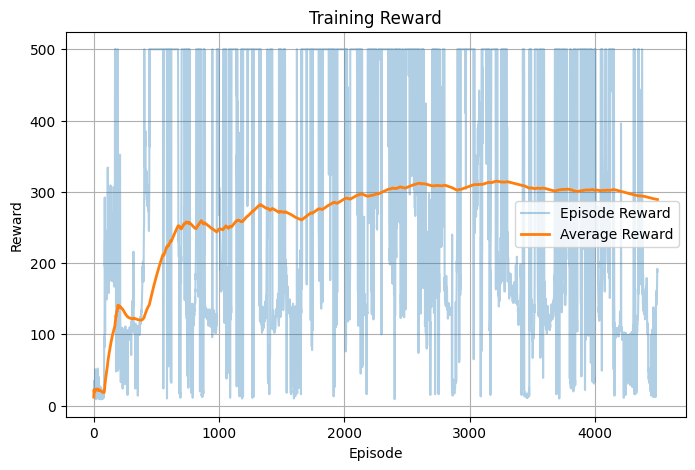

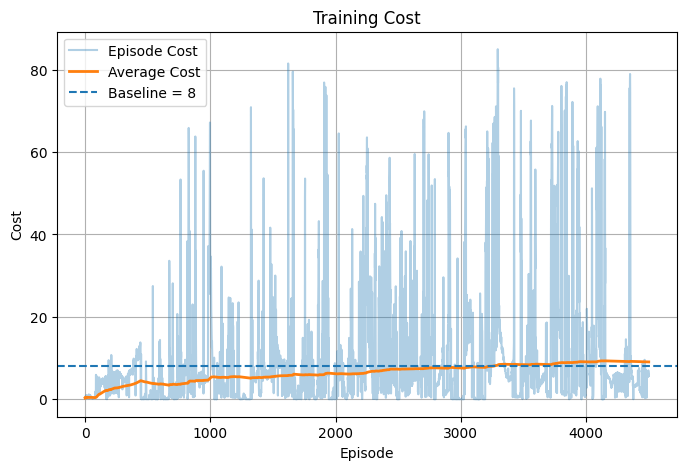

In [2]:
# -*- coding: utf-8 -*-
"""
CartPole-v1 with stage-wise CRPO-style training
Same CRPO style as your original:
    if constraint satisfied -> optimize reward
    else -> optimize constraint violation
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import gymnasium as gym
from collections import deque
import random
import copy
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# Replay Buffer
# =========================================================
class Buffer:
    def __init__(self, size=100000):
        self.buffer = deque(maxlen=size)

    def add(self, s, a_idx, adv, r, c, s_next, done):
        self.buffer.append((s, a_idx, adv, r, c, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a_idx, adv, r, c, s_next, done = zip(*batch)

        return (
            torch.tensor(np.array(s), dtype=torch.float32, device=device),
            torch.tensor(np.array(a_idx), dtype=torch.long, device=device).unsqueeze(1),
            torch.tensor(np.array(adv), dtype=torch.float32, device=device),
            torch.tensor(np.array(r), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(c), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.array(s_next), dtype=torch.float32, device=device),
            torch.tensor(np.array(done), dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)

# =========================================================
# Networks
# =========================================================
class Actor(nn.Module):
    def __init__(self, s_dim, n_actions=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, s):
        return self.net(s)   # logits


class Adversary(nn.Module):
    def __init__(self, s_dim, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, adv_dim),
            nn.Tanh()
        )

    def forward(self, s):
        return self.net(s)


class Critic(nn.Module):
    def __init__(self, s_dim, n_actions, adv_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(s_dim + n_actions + adv_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, s, a_onehot, adv):
        x = torch.cat([s, a_onehot, adv], dim=-1)
        return self.net(x)

# =========================================================
# Helpers
# =========================================================
def one_hot_actions(a_idx, n_actions=2):
    return F.one_hot(a_idx.squeeze(-1), num_classes=n_actions).float()

def soft_update(net, target_net, tau=0.005):
    for p, tp in zip(net.parameters(), target_net.parameters()):
        tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# =========================================================
# Adversarial CartPole
# =========================================================
class AdversarialCartPole:
    def __init__(self, max_steps=500):
        self.env = gym.make("CartPole-v1")
        self.max_steps = max_steps
        self.step_count = 0
        self.state = None

    def reset(self):
        s, _ = self.env.reset()
        self.state = np.array(s, dtype=np.float32)
        self.step_count = 0
        return self.state

    def step(self, action, adv):
        s_next, _, terminated, truncated, _ = self.env.step(int(action))
        x, x_dot, theta, theta_dot = s_next

        adv = np.array(adv, dtype=np.float32).reshape(-1)

        # adv[0] perturbs cart velocity
        # adv[1] perturbs pole angular velocity
        dv = float(np.clip(adv[0], -1.0, 1.0))
        dtheta_v = float(np.clip(adv[1], -1.0, 1.0))

        x_dot = x_dot + 0.015 * dv
        theta_dot = theta_dot + 0.015 * dtheta_v

        s_next = np.array([x, x_dot, theta, theta_dot], dtype=np.float32)
        self.state = s_next
        self.step_count += 1

        # Standard CartPole learning signal
        reward = 1.0

        # Softer cost for safety
        cost = max(0.0, abs(theta) - 0.10) + 0.25 * max(0.0, abs(x) - 1.5)
        cost = float(cost)

        done = terminated or truncated or (self.step_count >= self.max_steps)
        return s_next, reward, cost, done

# =========================================================
# Action selection
# =========================================================
def sample_actor_action(actor, s_np, n_actions=2, greedy=False, eps=0.0):
    if (not greedy) and (random.random() < eps):
        return random.randint(0, n_actions - 1)

    s_t = torch.tensor(s_np, dtype=torch.float32, device=device).unsqueeze(0)
    logits = actor(s_t)

    if greedy:
        a = torch.argmax(logits, dim=-1).item()
    else:
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample().item()
    return a

# =========================================================
# Evaluation
# =========================================================
def evaluate_policy(env, actor, adversary, n_actions, adv_scale=0.0, episodes=10):
    actor.eval()
    adversary.eval()

    rewards = []
    costs = []

    with torch.no_grad():
        for _ in range(episodes):
            s = env.reset()
            total_r = 0.0
            total_c = 0.0

            for _ in range(env.max_steps):
                a = sample_actor_action(actor, s, n_actions=n_actions, greedy=True, eps=0.0)

                s_t = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                adv = adversary(s_t).squeeze(0).cpu().numpy()
                adv = adv_scale * adv

                s_next, r, c, done = env.step(a, adv)

                total_r += r
                total_c += c
                s = s_next

                if done:
                    break

            rewards.append(total_r)
            costs.append(total_c)

    actor.train()
    adversary.train()

    return float(np.mean(rewards)), float(np.mean(costs))

# =========================================================
# Main Setup
# =========================================================
set_seed(42)

env = AdversarialCartPole(max_steps=500)
buffer = Buffer(size=100000)

s_dim = 4
n_actions = 2
adv_dim = 2

actor = Actor(s_dim, n_actions).to(device)
adversary = Adversary(s_dim, adv_dim).to(device)

# 4 critics like your other version
critic_r_o = Critic(s_dim, n_actions, adv_dim).to(device)
critic_r_p = Critic(s_dim, n_actions, adv_dim).to(device)
critic_u_o = Critic(s_dim, n_actions, adv_dim).to(device)
critic_u_p = Critic(s_dim, n_actions, adv_dim).to(device)

critic_r_o_target = copy.deepcopy(critic_r_o)
critic_r_p_target = copy.deepcopy(critic_r_p)
critic_u_o_target = copy.deepcopy(critic_u_o)
critic_u_p_target = copy.deepcopy(critic_u_p)

opt_actor = torch.optim.Adam(actor.parameters(), lr=5e-4)
opt_adv   = torch.optim.Adam(adversary.parameters(), lr=2e-4)

opt_r_o = torch.optim.Adam(critic_r_o.parameters(), lr=1e-3)
opt_r_p = torch.optim.Adam(critic_r_p.parameters(), lr=1e-3)
opt_u_o = torch.optim.Adam(critic_u_o.parameters(), lr=1e-3)
opt_u_p = torch.optim.Adam(critic_u_p.parameters(), lr=1e-3)

gamma = 0.99
tau = 0.005
num_episodes = 4500
batch_size = 128
start_train_after = 1000

# same style threshold idea
b = 20.0

# stage schedule
stage1_end = 800    # learn nominal CartPole first
stage2_end = 1100   # turn on weak adversary, no CRPO yet

reward_hist = []
cost_hist = []
eval_nom_reward_hist = []
eval_nom_cost_hist = []
eval_adv_reward_hist = []
eval_adv_cost_hist = []

best_score = -1e9
best_actor_state = None
best_adv_state = None

# =========================================================
# Training Loop
# =========================================================
for ep in tqdm(range(num_episodes), desc="Training"):
    s = env.reset()
    total_r = 0.0
    total_c = 0.0

    # exploration
    eps = max(0.02, 0.20 * (0.995 ** ep))

    # ---------------------------
    # Stage-wise training
    # ---------------------------
    if ep < stage1_end:
        stage = 1
        adv_scale = 0.0
        adv_train = False
        use_crpo = False

    elif ep < stage2_end:
        stage = 2
        adv_scale = 0.05
        adv_train = True
        use_crpo = False

    else:
        stage = 3
        adv_scale = 0.03
        adv_train = True
        use_crpo = True

    for t in range(env.max_steps):
        # actor action
        a = sample_actor_action(actor, s, n_actions=n_actions, greedy=False, eps=eps)

        # adversary action
        s_t = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            adv = adversary(s_t).squeeze(0).cpu().numpy()
            adv = adv_scale * adv

        s_next, r, c, done = env.step(a, adv)

        buffer.add(s, a, adv, r, c, s_next, done)

        s = s_next
        total_r += r
        total_c += c

        # ---------------------------
        # Learning
        # ---------------------------
        if len(buffer) > start_train_after:
            S, A_idx, ADV, R, C, S_next, D = buffer.sample(batch_size)
            A_onehot = one_hot_actions(A_idx, n_actions=n_actions)

            # ===== target computations =====
            with torch.no_grad():
                not_done = 1.0 - D

                next_logits = actor(S_next)
                next_probs = torch.softmax(next_logits, dim=-1)

                ADV_next = adv_scale * adversary(S_next)

                q_ro_list, q_rp_list, q_uo_list, q_up_list = [], [], [], []

                for a_i in range(n_actions):
                    a_next_idx = torch.full((S_next.shape[0], 1), a_i, dtype=torch.long, device=device)
                    a_next_oh = one_hot_actions(a_next_idx, n_actions=n_actions)

                    q_ro_list.append(critic_r_o_target(S_next, a_next_oh, ADV_next))
                    q_rp_list.append(critic_r_p_target(S_next, a_next_oh, ADV_next))
                    q_uo_list.append(critic_u_o_target(S_next, a_next_oh, ADV_next))
                    q_up_list.append(critic_u_p_target(S_next, a_next_oh, ADV_next))

                q_ro_all = torch.cat(q_ro_list, dim=1)
                q_rp_all = torch.cat(q_rp_list, dim=1)
                q_uo_all = torch.cat(q_uo_list, dim=1)
                q_up_all = torch.cat(q_up_list, dim=1)

                exp_q_ro = (next_probs * q_ro_all).sum(dim=1, keepdim=True)
                exp_q_rp = (next_probs * q_rp_all).sum(dim=1, keepdim=True)
                exp_q_uo = (next_probs * q_uo_all).sum(dim=1, keepdim=True)
                exp_q_up = (next_probs * q_up_all).sum(dim=1, keepdim=True)

                target_r_o = R + gamma * not_done * exp_q_ro
                target_r_p = R + gamma * not_done * exp_q_rp
                target_u_o = C + gamma * not_done * exp_q_uo
                target_u_p = C + gamma * not_done * exp_q_up

            # ===== critic updates =====
            loss_ro = ((critic_r_o(S, A_onehot, ADV) - target_r_o) ** 2).mean()
            opt_r_o.zero_grad()
            loss_ro.backward()
            torch.nn.utils.clip_grad_norm_(critic_r_o.parameters(), 1.0)
            opt_r_o.step()

            loss_rp = ((critic_r_p(S, A_onehot, ADV) - target_r_p) ** 2).mean()
            opt_r_p.zero_grad()
            loss_rp.backward()
            torch.nn.utils.clip_grad_norm_(critic_r_p.parameters(), 1.0)
            opt_r_p.step()

            loss_uo = ((critic_u_o(S, A_onehot, ADV) - target_u_o) ** 2).mean()
            opt_u_o.zero_grad()
            loss_uo.backward()
            torch.nn.utils.clip_grad_norm_(critic_u_o.parameters(), 1.0)
            opt_u_o.step()

            loss_up = ((critic_u_p(S, A_onehot, ADV) - target_u_p) ** 2).mean()
            opt_u_p.zero_grad()
            loss_up.backward()
            torch.nn.utils.clip_grad_norm_(critic_u_p.parameters(), 1.0)
            opt_u_p.step()

            soft_update(critic_r_o, critic_r_o_target, tau)
            soft_update(critic_r_p, critic_r_p_target, tau)
            soft_update(critic_u_o, critic_u_o_target, tau)
            soft_update(critic_u_p, critic_u_p_target, tau)

            # =====================================================
            # ACTOR UPDATE: SAME CRPO STYLE AS YOUR ORIGINAL
            # if feasible -> maximize reward
            # else       -> reduce violation only
            # =====================================================
            logits = actor(S)
            probs = torch.softmax(logits, dim=-1)

            ADV_fixed = adv_scale * adversary(S).detach()

            q_r_vals = []
            q_u_vals = []
            for a_i in range(n_actions):
                a_i_idx = torch.full((S.shape[0], 1), a_i, dtype=torch.long, device=device)
                a_i_oh = one_hot_actions(a_i_idx, n_actions=n_actions)

                q_r_vals.append(critic_r_o(S, a_i_oh, ADV_fixed))
                q_u_vals.append(critic_u_o(S, a_i_oh, ADV_fixed))

            q_r_all = torch.cat(q_r_vals, dim=1)
            q_u_all = torch.cat(q_u_vals, dim=1)

            exp_q_r = (probs * q_r_all).sum(dim=1, keepdim=True)
            exp_q_u = (probs * q_u_all).sum(dim=1, keepdim=True)

            if not use_crpo:
                actor_loss = -exp_q_r.mean()

                entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1).mean()
                actor_loss = actor_loss - 0.02 * entropy
            else:
                if exp_q_u.mean().item() <= b:
                    actor_loss = -exp_q_r.mean()

                    entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=1).mean()
                    actor_loss = actor_loss - 0.02 * entropy
                else:
                    actor_loss = torch.relu(exp_q_u - b).mean()

            opt_actor.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
            opt_actor.step()

            # =====================================================
            # ADVERSARY UPDATE: SAME STYLE AS YOUR ORIGINAL IDEA
            # if feasible -> hurt reward
            # else       -> increase violation
            # =====================================================
            if adv_train and (t % 25 == 0):
                ADV_pred = adv_scale * adversary(S)

                logits_fixed = actor(S).detach()
                probs_fixed = torch.softmax(logits_fixed, dim=-1)

                q_r_adv_vals = []
                q_u_adv_vals = []

                for a_i in range(n_actions):
                    a_i_idx = torch.full((S.shape[0], 1), a_i, dtype=torch.long, device=device)
                    a_i_oh = one_hot_actions(a_i_idx, n_actions=n_actions)

                    q_r_adv_vals.append(critic_r_p(S, a_i_oh, ADV_pred))
                    q_u_adv_vals.append(critic_u_p(S, a_i_oh, ADV_pred))

                q_r_adv_all = torch.cat(q_r_adv_vals, dim=1)
                q_u_adv_all = torch.cat(q_u_adv_vals, dim=1)

                exp_q_r_adv = (probs_fixed * q_r_adv_all).sum(dim=1, keepdim=True)
                exp_q_u_adv = (probs_fixed * q_u_adv_all).sum(dim=1, keepdim=True)

                if not use_crpo:
                    adv_loss = exp_q_r_adv.mean()
                else:
                    if exp_q_u_adv.mean().item() <= b:
                        adv_loss = exp_q_r_adv.mean()
                    else:
                        adv_loss = -torch.relu(exp_q_u_adv - b).mean()

                opt_adv.zero_grad()
                adv_loss.backward()
                torch.nn.utils.clip_grad_norm_(adversary.parameters(), 1.0)
                opt_adv.step()

        if done:
            break

    reward_hist.append(total_r)
    cost_hist.append(total_c)

    # evaluation every 20 episodes
    if (ep + 1) % 20 == 0:
        eval_nom_r, eval_nom_c = evaluate_policy(env, actor, adversary, n_actions, adv_scale=0.0, episodes=10)
        eval_adv_r, eval_adv_c = evaluate_policy(env, actor, adversary, n_actions, adv_scale=adv_scale, episodes=10)

        eval_nom_reward_hist.append(eval_nom_r)
        eval_nom_cost_hist.append(eval_nom_c)
        eval_adv_reward_hist.append(eval_adv_r)
        eval_adv_cost_hist.append(eval_adv_c)

        print(
            f"Ep {ep+1:4d} | Stage {stage} | "
            f"TrainReward: {total_r:6.1f} | TrainCost: {total_c:7.2f} | "
            f"AvgReward(20): {np.mean(reward_hist[-20:]):6.1f} | AvgCost(20): {np.mean(cost_hist[-20:]):7.2f} | "
            f"EvalNomReward: {eval_nom_r:6.1f} | EvalAdvReward: {eval_adv_r:6.1f} | EvalAdvCost: {eval_adv_c:7.2f} | "
            f"Eps: {eps:.3f}"
        )

        score = eval_adv_r - 2.0 * eval_adv_c
        if score > best_score:
            best_score = score
            best_actor_state = copy.deepcopy(actor.state_dict())
            best_adv_state = copy.deepcopy(adversary.state_dict())

# =========================================================
# Load best checkpoint
# =========================================================
if best_actor_state is not None:
    actor.load_state_dict(best_actor_state)
    adversary.load_state_dict(best_adv_state)
    print("Loaded best checkpoint.")

# =========================================================
# Final evaluation
# =========================================================
final_nom_r, final_nom_c = evaluate_policy(env, actor, adversary, n_actions, adv_scale=0.0, episodes=20)
final_adv_r, final_adv_c = evaluate_policy(env, actor, adversary, n_actions, adv_scale=0.03, episodes=20)

print(f"\nFinal Eval without adversary -> Reward: {final_nom_r:.2f}, Cost: {final_nom_c:.2f}")
print(f"Final Eval with adversary    -> Reward: {final_adv_r:.2f}, Cost: {final_adv_c:.2f}")

# =========================================================
# Save results
# =========================================================
avg_reward = np.cumsum(reward_hist) / np.arange(1, len(reward_hist) + 1)
avg_cost = np.cumsum(cost_hist) / np.arange(1, len(cost_hist) + 1)

df = pd.DataFrame({
    "Episode": np.arange(1, len(reward_hist) + 1),
    "Reward": reward_hist,
    "Cost": cost_hist,
    "Average Reward": avg_reward,
    "Average Cost": avg_cost,
})
df.to_excel("CartPoleV1_stagewise_CRPO_results.xlsx", index=False)
print("Saved: CartPoleV1_stagewise_CRPO_results.xlsx")

# =========================================================
# Plot
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(reward_hist, alpha=0.35, label="Episode Reward")
plt.plot(avg_reward, linewidth=2, label="Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(cost_hist, alpha=0.35, label="Episode Cost")
plt.plot(avg_cost, linewidth=2, label="Average Cost")
plt.axhline(y=8, linestyle="--", label="Baseline = 8")
plt.xlabel("Episode")
plt.ylabel("Cost")
plt.title("Training Cost")
plt.legend()
plt.grid(True)
plt.show()